In [17]:
import torch
import torchvision
from torchvision import transforms
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.transforms import functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

In [18]:
# Load the Model

model = maskrcnn_resnet50_fpn(pretrained=True)
model.eval()

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [19]:
def load_image(image_path):
    image = Image.open(image_path)

    transform = transforms.Compose([transforms.ToTensor()])
    return transform(image).unsqueeze(0)

In [20]:
load_image('jungle.jpg');

In [21]:
def predict(image):
  image_tensor = load_image(image)
  with torch.no_grad():
    prediction = model(image_tensor)
    return prediction

In [22]:
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter',
    'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet',
    'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster',
    'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

In [23]:
prediction = predict('jungle.jpg')
prediction

[{'boxes': tensor([[155.6961,   7.3752, 590.1880, 385.6956]]),
  'labels': tensor([24]),
  'scores': tensor([0.9993]),
  'masks': tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            ...,
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.],
            [0., 0., 0.,  ..., 0., 0., 0.]]]])}]

In [24]:
masks = prediction[0]['masks'].cpu().numpy()

In [25]:
len(masks)

1

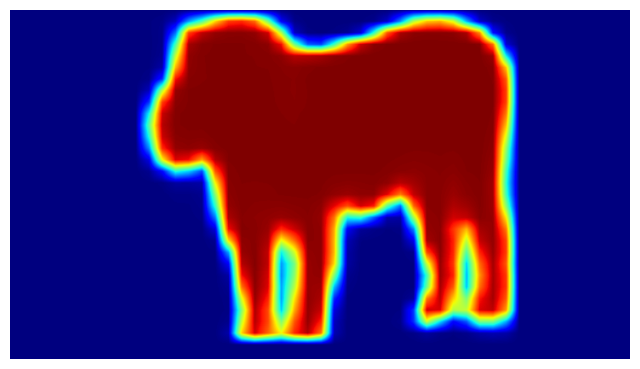

In [26]:
# Combine all 56 masks into a single image overlay
combined_masks = masks.sum(axis=0)[0]

# Display the combined result
plt.figure(figsize=(8, 8))
plt.imshow(combined_masks, cmap='jet')
plt.axis('off')
plt.show()

In [27]:
COCO_INSTANCE_CATEGORY_NAMES [prediction[0]['labels'][0] - 1]

'zebra'

In [28]:
COCO_INSTANCE_CATEGORY_NAMES [prediction[0]['labels'][1] - 1]

IndexError: index 1 is out of bounds for dimension 0 with size 1

In [ ]:
# from torchvision.ops import boxes
# def visualize_prediction(image, prediction):

#   plt.imshow(image)

#   boxes = prediction[0]['boxes'].cpu().numpy().astype(np.int32)
#   labels = prediction[0]['labels'].cpu().numpy().astype(np.int32)
#   scores = prediction[0]['scores'].cpu().numpy()
#   masks = prediction[0]['masks'].cpu().numpy()

#   keep = scores > 0.5
#   boxes = boxes[keep]
#   labels = labels[keep]
#   scores = scores[keep]
#   masks = masks[keep] # Keep only masks > 0.5

#   for box, label, score, mask in zip(boxes, labels, scores, masks):
#       box = box.tolist()
#       x1, y1, x2, y2 = box
#       label = COCO_INSTANCE_CATEGORY_NAMES[label - 1]
#       plt.gca().add_patch(plt.Rectangle(
#         (x1, y1), x2 - x1, y2 - y1, fill=False, color='red',linewidth=2))
#       plt.text(x1, y1, f'{label}: {score:.2f}',
#              fontsize=12, color='white')
#       mask = mask.reshape(image.reshape(-1, 3).shape)
#       plt.imshow(mask, alpha=0.25)
# plt.axis('off')
# plt.show()

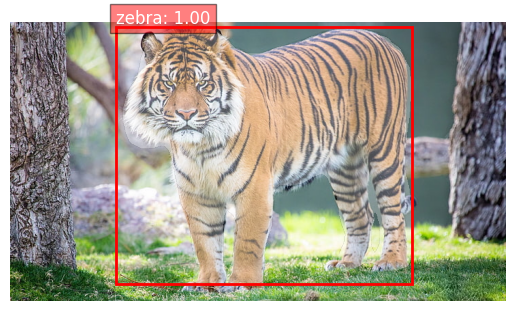

In [29]:
from torchvision.ops import boxes
import numpy as np
import matplotlib.pyplot as plt

def visualize_prediction(image_path, prediction):
    # 1. Load and display the actual image background first
    image = Image.open(image_path)
    plt.imshow(image)

    # 2. Extract data from prediction
    boxes = prediction[0]['boxes'].cpu().numpy().astype(np.int32)
    labels = prediction[0]['labels'].cpu().numpy().astype(np.int32)
    scores = prediction[0]['scores'].cpu().numpy()
    masks = prediction[0]['masks'].cpu().numpy()

    # 3. Filter out low-confidence predictions
    keep = scores > 0.5
    boxes = boxes[keep]
    labels = labels[keep]
    scores = scores[keep]
    masks = masks[keep]

    # 4. Loop through and draw everything
    for box, label, score, mask in zip(boxes, labels, scores, masks):
        x1, y1, x2, y2 = box.tolist()
        label_text = COCO_INSTANCE_CATEGORY_NAMES[label - 1]

        # Draw bounding box
        plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='red', linewidth=2))

        # Add text label
        plt.text(x1, y1 - 5, f'{label_text}: {score:.2f}', fontsize=12, color='white', bbox=dict(facecolor='red', alpha=0.5))

        # FIX: Isolate the 2D mask channel and create a boolean mask where confidence > 0.5
        mask_2d = mask[0] > 0.5

        # Create an RGB overlay for the mask (e.g., green tint)
        overlay = np.zeros((*mask_2d.shape, 4))  # Height x Width x RGBA
        overlay[mask_2d] = [1, 1, 1, 0.3]       # White color ([1, 1, 1]) with 30% transparency       # Green color with 40% transparency

        # Display the mask overlay seamlessly on top
        plt.imshow(overlay)

    plt.axis('off')
    plt.show()

visualize_prediction('jungle.jpg', prediction)

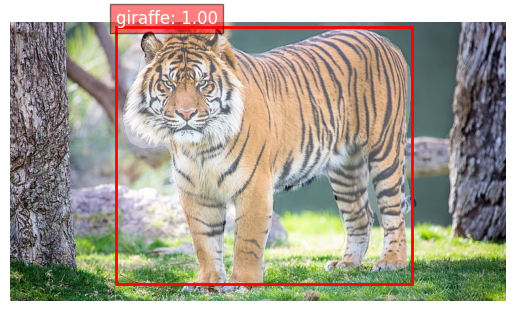

In [30]:
# GEMINI
from torchvision.ops import boxes
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def visualize_prediction(image_path, prediction):
    # 1. Load and display the actual image background first
    image = Image.open(image_path)
    plt.imshow(image)

    # 2. Extract data from prediction
    boxes = prediction[0]['boxes'].cpu().numpy().astype(np.int32)
    labels = prediction[0]['labels'].cpu().numpy().astype(np.int32)
    scores = prediction[0]['scores'].cpu().numpy()
    masks = prediction[0]['masks'].cpu().numpy()

    # 3. Filter out low-confidence predictions
    keep = scores > 0.5
    boxes = boxes[keep]
    labels = labels[keep]
    scores = scores[keep]
    masks = masks[keep]

    # 4. Loop through and draw everything
    for box, label, score, mask in zip(boxes, labels, scores, masks):
        x1, y1, x2, y2 = box.tolist()

        # FIX: Removed the "- 1" so the index matches the COCO class list perfectly
        label_text = COCO_INSTANCE_CATEGORY_NAMES[label]

        # Draw bounding box
        plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='red', linewidth=2))

        # Add text label
        plt.text(x1, y1 - 5, f'{label_text}: {score:.2f}', fontsize=12, color='white', bbox=dict(facecolor='red', alpha=0.5))

        # Isolate the 2D mask channel and create a boolean mask where confidence > 0.5
        mask_2d = mask[0] > 0.5

        # Create an RGBA overlay (Height x Width x 4)
        overlay = np.zeros((*mask_2d.shape, 4))

        # Highlight objects with a soft, semi-transparent white look
        overlay[mask_2d] = [1, 1, 1, 0.3]

        # Display the mask overlay seamlessly on top
        plt.imshow(overlay)

    plt.axis('off')
    plt.show()

# Run the fixed function on your jungle image
visualize_prediction('jungle.jpg', prediction)